## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x00000246D404C280> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,2.030213
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.997432
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.882009
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.242316
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.093469


In [6]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0


In [7]:
timeline_file[['NUTS3_NAME', 'dt_placement']].value_counts().sort_values(ascending=False)

NUTS3_NAME  dt_placement
σερρες      2010-01-02      154
            2010-01-17      154
            2010-01-03      154
            2010-01-04      154
            2010-01-05      154
                           ... 
πιερια      2022-12-28       45
            2022-12-29       45
            2022-12-23       45
            2022-12-14       45
            2022-12-31       45
Length: 33236, dtype: int64

In [8]:
wnv_file[['NUTS3_NAME', 'dt_placement']].value_counts().sort_values(ascending=False)

NUTS3_NAME  dt_placement
ημαθια      2010-06         1
            2012-07         1
            2010-10         1
            2010-11         1
            2011-06         1
                           ..
χαλκιδικη   2022-07         1
            2022-08         1
            2022-09         1
            2022-10         1
            2022-11         1
Length: 378, dtype: int64

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,2.030213,13934.000000,13934.000000,NaN,NaN,NaN
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.997432,13934.000000,13934.000000,NaN,NaN,NaN
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.882009,13934.000000,13934.000000,NaN,NaN,NaN
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.242316,13934.000000,13934.000000,NaN,NaN,NaN
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961450,40.522520,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.093469,13934.000000,13934.000000,NaN,NaN,NaN


In [11]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0


### Calculate accumulated rainfall ###

In [12]:
timeline_file.shape

(3067208, 38)

In [13]:
dataset = pd.DataFrame()
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset = dataset.append(temp_df)

dataset.reset_index(drop=True, inplace=True)

dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,3.768066,13965.000000,13965.000000,NaN,NaN,NaN,3.768066,3.768066,3.768066
1,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,2.864009,13965.000000,13965.000000,NaN,NaN,NaN,6.632075,6.632075,6.632075
2,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13776.000000,NaN,NaN,NaN,1.146590,13789.500000,13906.500000,NaN,NaN,NaN,7.778665,7.778665,7.778665
3,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13717.500000,NaN,NaN,NaN,0.413468,13789.500000,13877.250000,NaN,NaN,NaN,8.192133,8.192133,8.192133
4,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13682.400000,NaN,NaN,NaN,2.318093,13789.500000,13859.700000,NaN,NaN,NaN,10.510226,10.510226,10.510226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067203,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-27,27,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14157.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,14014.000000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.756312,1446.142168
3067204,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14043.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,13957.000000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.090257,1446.142168
3067205,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-29,29,12,2022,0.440798,0.182004,-0.353630,-0.182004,0.145205,0.121073,-0.073761,-0.121073,0.000000,0.000000,0.000000,0.000000,14154.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,14012.500000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.090257,1446.142168
3067206,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-30,30,12,2022,0.440798,0.182004,-0.353630,-0.182004,0.145205,0.121073,-0.073761,-0.121073,0.000000,0.000000,0.000000,0.000000,14110.000000,13907.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,14008.500000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.000000,1446.142168


### Add mosqutio predictions using trained model ###

In [14]:
model = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [15]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [16]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [17]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [18]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [19]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [20]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

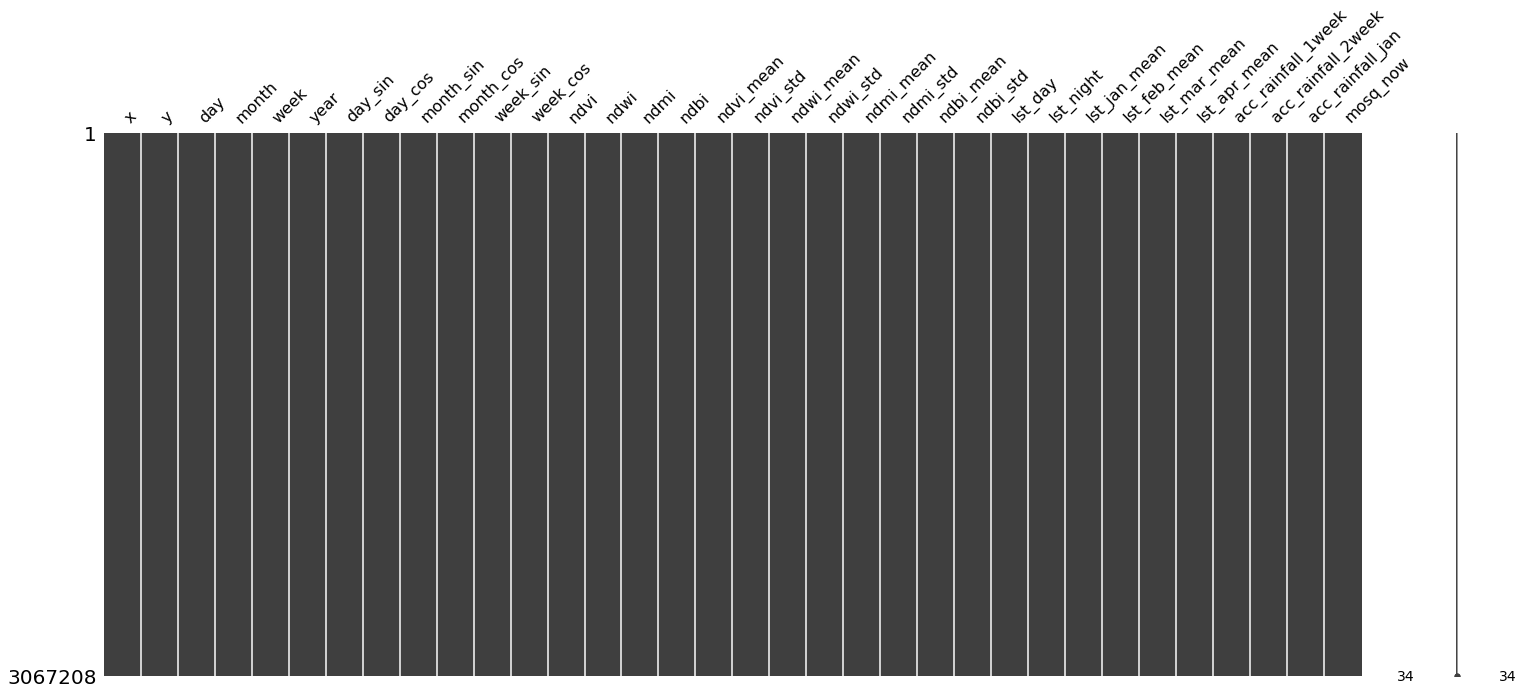

In [21]:
missingno.matrix(dataset_mamoth)

In [22]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [23]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [24]:
predictions = give_predictions(model, dataset_mamoth)

In [25]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.784110,40.821750,2010-01-01,13
1,21.784110,40.821750,2010-01-02,14
2,21.784110,40.821750,2010-01-03,17
3,21.784110,40.821750,2010-01-04,27
4,21.784110,40.821750,2010-01-05,25
...,...,...,...,...
3067203,24.069540,40.979960,2022-12-27,1
3067204,24.069540,40.979960,2022-12-28,1
3067205,24.069540,40.979960,2022-12-29,1
3067206,24.069540,40.979960,2022-12-30,1


<AxesSubplot:>

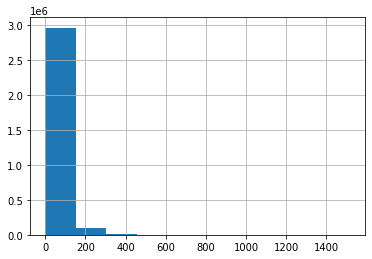

In [26]:
mosqutio_predictions.mosq_pred.hist()

In [27]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

In [28]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,3.768066,13965.000000,13965.000000,NaN,NaN,NaN,3.768066,3.768066,3.768066,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13
1,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13893.000000,14037.000000,NaN,NaN,NaN,13893.000000,NaN,NaN,NaN,2.864009,13965.000000,13965.000000,NaN,NaN,NaN,6.632075,6.632075,6.632075,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,14
2,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13776.000000,NaN,NaN,NaN,1.146590,13789.500000,13906.500000,NaN,NaN,NaN,7.778665,7.778665,7.778665,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,17
3,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13717.500000,NaN,NaN,NaN,0.413468,13789.500000,13877.250000,NaN,NaN,NaN,8.192133,8.192133,8.192133,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,27
4,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784110,40.821750,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14037.000000,13542.000000,14037.000000,NaN,NaN,NaN,13682.400000,NaN,NaN,NaN,2.318093,13789.500000,13859.700000,NaN,NaN,NaN,10.510226,10.510226,10.510226,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067203,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-27,27,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14157.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,14014.000000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.756312,1446.142168,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,1
3067204,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14043.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,13957.000000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.090257,1446.142168,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,1
3067205,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-29,29,12,2022,0.440798,0.182004,-0.353630,-0.182004,0.145205,0.121073,-0.073761,-0.121073,0.000000,0.000000,0.000000,0.000000,14154.000000,13871.000000,13899.500000,14189.678571,14298.838710,14298.838710,13672.516129,13786.964286,13745.129032,13745.129032,0.000000,14012.500000,13786.008065,13988.321429,14021.983871,14021.983871,0.000000,0.090257,1446.142168,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,1
3067206,EL52,κεντρικη μακεδονια,EL526,σερρες,24.069540,40.979960,2022-12-30,30,12,2022,0.440798,0.182004,-0.353630,-0.182004,0.145205,0.121073,-0.073761,-0.121073,0.000000,0.000000,0.000000,0.000000,14110.000000,13907.000000,13899.500000,1

In [29]:
grouped = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_grouped = grouped.mean()
dataset_grouped

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,2010-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14262.127273,14005.407407,14262.127273,NaN,NaN,NaN,14005.407407,NaN,NaN,NaN,1.216681,14136.074074,14136.074074,NaN,NaN,NaN,1.216681,1.216681,1.216681,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,17.781818
1,2010-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14350.503937,14039.913386,14350.503937,NaN,NaN,NaN,14039.913386,NaN,NaN,NaN,0.020066,14195.208661,14195.208661,NaN,NaN,NaN,0.020066,0.020066,0.020066,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,15.803150
2,2010-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14266.670330,14021.142857,14266.670330,NaN,NaN,NaN,14021.142857,NaN,NaN,NaN,0.000223,14143.906593,14143.906593,NaN,NaN,NaN,0.000223,0.000223,0.000223,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,11.582418
3,2010-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14220.556818,13991.261364,14220.556818,NaN,NaN,NaN,13991.261364,NaN,NaN,NaN,0.406945,14105.909091,14105.909091,NaN,NaN,NaN,0.406945,0.406945,0.406945,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13.511364
4,2010-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14455.555556,14110.933333,14455.555556,NaN,NaN,NaN,14110.933333,NaN,NaN,NaN,1.073789,14283.244444,14283.244444,NaN,NaN,NaN,1.073789,1.073789,1.073789,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,25.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,31.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14257.087912,13814.912088,14066.867167,14351.524725,14398.353421,14398.353421,13633.095356,13714.459576,13666.662177,13666.662177,0.000000,14036.000000,13849.981261,14032.992151,14032.507799,14032.507799,0.010527,0.018527,1077.473491,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,10.329670
33232,2022-12-31,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,31.000000,12.000000,2022.000000,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,14220.125000,13826.840909,14059.543512,14303.178977,14298.990836,14298.990836,13628.980230,13709.562500,13664.076979,13664.076979,0.000000,14023.482955,13844.261871,14006.370739,13981.533908,13981.533908,0.428337,0.651870,1158.041206,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,62.818182
33233,2022-12-31,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,31.000000,12.000000,2022.000000,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,14247.533333,13901.000000,14102.108244,14304.360317,14292.009319,14292.009319,13680.272975,13767.332540,13717.169176,13717.169176,0.000000,14074.266667,13891.190609,14035.846429,14004.589247,14004.589

<AxesSubplot:>

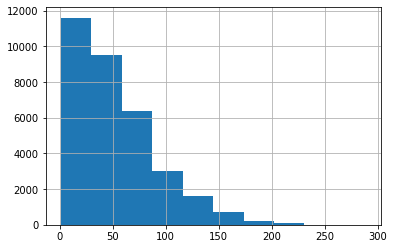

In [30]:
dataset_grouped.mosq_pred.hist()

In [31]:
dataset_grouped = convert_temperature(dataset_grouped)

<AxesSubplot:>

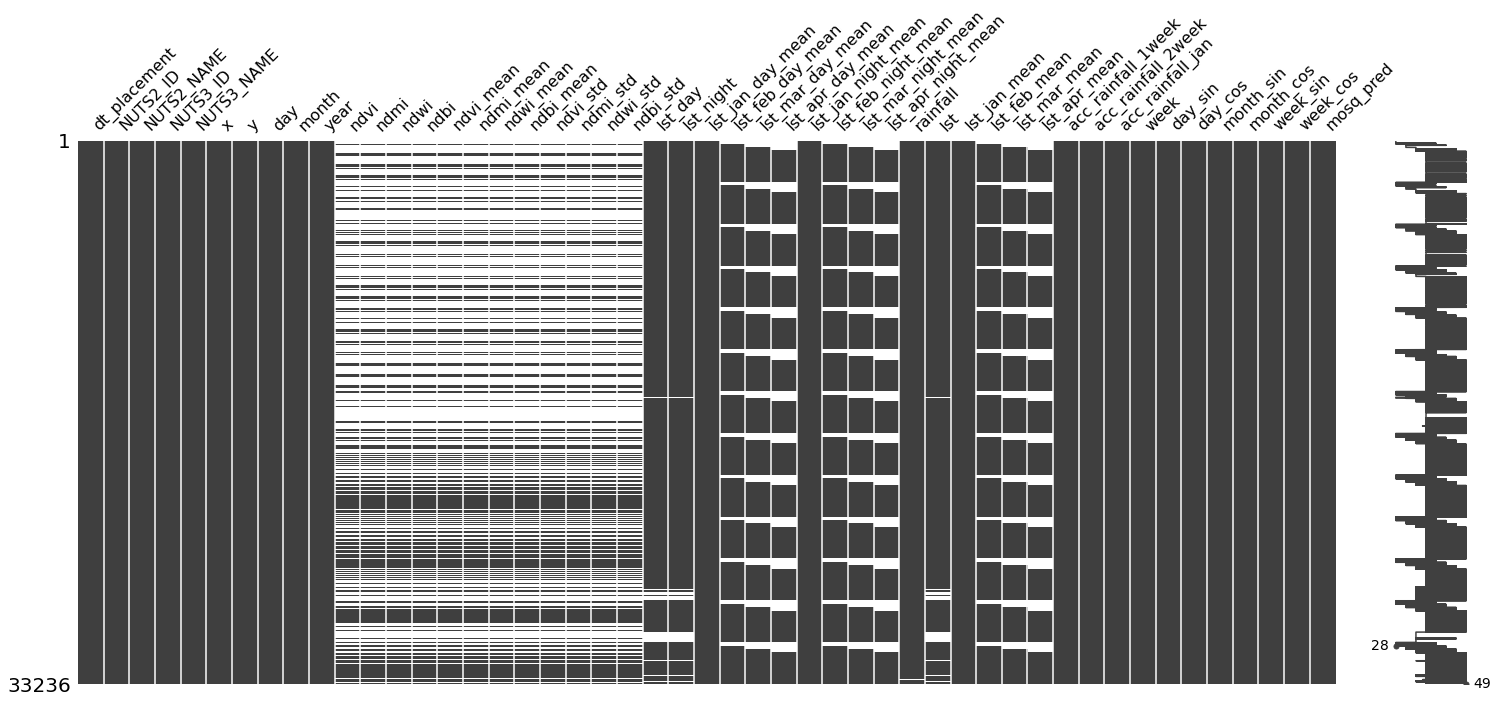

In [32]:
missingno.matrix(dataset_grouped)

### Add Bio Variables ###

In [39]:
bio_values = []

for region in dataset_grouped.NUTS3_NAME.unique():
    for year in dataset_grouped.year.unique():
        for month in dataset_grouped.month.unique():
            filtered_df = dataset_grouped.loc[(dataset_grouped['year'] == year) & (dataset_grouped['NUTS3_NAME'] == region) & (dataset_grouped['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [40]:
bio_values_df = pd.DataFrame(bio_values)

In [41]:
dataset = pd.merge(dataset_grouped, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [42]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,12.092545,NaN,NaN,NaN,6.958148,NaN,NaN,NaN,1.216681,9.525347,9.571481,NaN,NaN,NaN,1.216681,1.216681,1.216681,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,17.781818,-0.015091,12.092545,81.134845
1,2010-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,13.860079,NaN,NaN,NaN,7.648268,NaN,NaN,NaN,0.020066,10.754173,10.754173,NaN,NaN,NaN,0.020066,0.020066,0.020066,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,15.803150,-2.877717,13.860079,42.311748
2,2010-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,12.183407,NaN,NaN,NaN,7.272857,NaN,NaN,NaN,0.000223,9.728132,9.728132,NaN,NaN,NaN,0.000223,0.000223,0.000223,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,11.582418,-4.895934,12.183407,53.173589
3,2010-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13.511364,-3.823409,11.261136,81.491186
4,2010-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,15.961111,NaN,NaN,NaN,9.068667,NaN,NaN,NaN,1.073789,12.514889,12.514889,NaN,NaN,NaN,1.073789,1.073789,1.073789,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,25.200000,1.550444,15.961111,81.927242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,31.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.991758,3.148242,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.000000,7.570000,3.849625,7.509843,7.500156,7.500156,0.010527,0.018527,1077.473491,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,10.329670,-0.776374,13.218571,13.285493
33232,2022-12-31,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,31.000000,12.000000,2022.000000,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,11.252500,3.386818,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.000000,7.319659,3.735237,6.977415,6.480678,6.480678,0.428337,0.651870,1158.041206,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,62.818182,-1.147727,12.883636,7.642274
33233,2022-12-31,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,31.000000,12.000000,2022.000000,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,11.800667,4.870000,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.000000,8.335333,4.673812,7.566929,6.941785,6.941785

<AxesSubplot:>

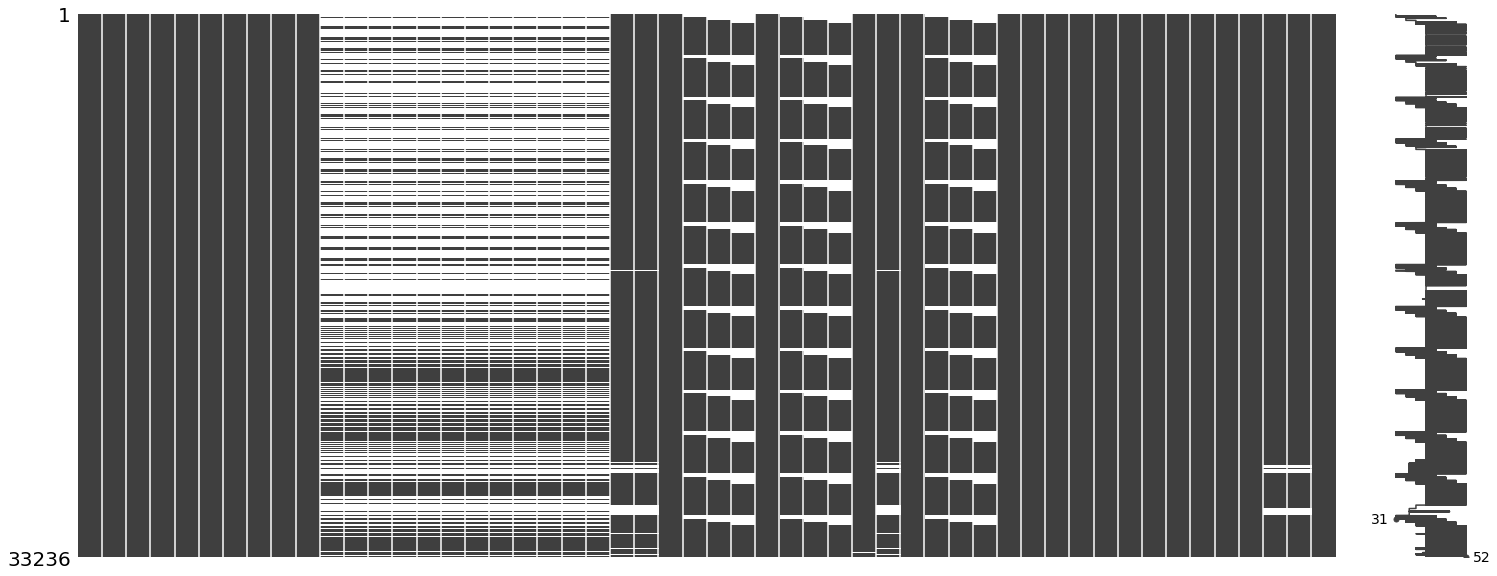

In [43]:
missingno.matrix(dataset)

In [46]:
dataset = dataset.astype({"day":"int","month":"int", "year":"int"})

In [47]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [48]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [49]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,12.092545,NaN,NaN,NaN,6.958148,NaN,NaN,NaN,1.216681,9.525347,9.571481,NaN,NaN,NaN,1.216681,1.216681,1.216681,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,17.781818,-0.015091,12.092545,81.134845,2010-01
1,2010-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,13.860079,NaN,NaN,NaN,7.648268,NaN,NaN,NaN,0.020066,10.754173,10.754173,NaN,NaN,NaN,0.020066,0.020066,0.020066,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,15.803150,-2.877717,13.860079,42.311748,2010-01
2,2010-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,12.183407,NaN,NaN,NaN,7.272857,NaN,NaN,NaN,0.000223,9.728132,9.728132,NaN,NaN,NaN,0.000223,0.000223,0.000223,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,11.582418,-4.895934,12.183407,53.173589,2010-01
3,2010-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,13.511364,-3.823409,11.261136,81.491186,2010-01
4,2010-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,15.961111,NaN,NaN,NaN,9.068667,NaN,NaN,NaN,1.073789,12.514889,12.514889,NaN,NaN,NaN,1.073789,1.073789,1.073789,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,25.200000,1.550444,15.961111,81.927242,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,31,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.991758,3.148242,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.000000,7.570000,3.849625,7.509843,7.500156,7.500156,0.010527,0.018527,1077.473491,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,10.329670,-0.776374,13.218571,13.285493,2022-12
33232,2022-12-31,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,31,12,2022,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,11.252500,3.386818,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.000000,7.319659,3.735237,6.977415,6.480678,6.480678,0.428337,0.651870,1158.041206,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,62.818182,-1.147727,12.883636,7.642274,2022-12
33233,2022-12-31,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,31,12,2022,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,11.800667,4.870000,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.000000,8.335333,4.673812,7.566929,6.941785,6.941785,1.072827,3.092039,1224.182744,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,

In [61]:
grouped = dataset.groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)
grouped_mosq = dataset.groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)


dataset_month = grouped.mean()
dataset_month_mosq = grouped.sum()


dataset_month

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.435606,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,33.659824,-0.015091,12.092545,81.134845
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,16.000000,1.000000,2010.000000,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,23.875032,-2.877717,13.860079,42.311748
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,16.000000,1.000000,2010.000000,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,20.364055,-4.895934,12.183407,53.173589
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,7.387097,0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,28.042522,-3.823409,11.261136,81.491186
4,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,36.475986,1.550444,15.961111,81.927242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,16.000000,12.000000,2022.000000,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,11.139610,3.633616,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,7.386613,3.849625,7.509843,7.500156,7.500156,3.368094,7.215676,1073.761431,50.129032,-0.000000,-0.000000,-0.000000,1.000000,-0.329750,0.931265,16.211627,-0.776374,13.218571,13.285493
1088,2022-12,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,16.000000,12.000000,2022.000000,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,11.136942,3.200919,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,7.168931,3.735237,6.977415,6.480678,6.480678,1.949946,4.340783,1155.499660,50.129032,0.000000,-0.000000,-0.000000,1.000000,-0.329750,0.931265,43.517595,-1.147727,12.883636,7.642274
1089,2022-12,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,16.000000,12.000000,2022.000000,0.348460,0.058114,-0.295928,-0.058114,0.333715,0.067023,-0.277636,-0.067023,0.053367,0.0

In [62]:
dataset_month_mosq

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,688.692167,1257.132387,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,191.236182,83.771360,294.151693,0.000000,0.000000,0.000000,126.601002,0.000000,0.000000,0.000000,81.134845,137.503771,210.635122,0.000000,0.000000,0.000000,474.491044,799.674200,1115.163154,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,1043.454545,-0.467818,374.868909,2515.180205
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,717.325501,1261.556131,496,31,62310,0.350987,0.143404,-0.113831,-0.143404,0.344637,0.177598,-0.064807,-0.177598,0.085027,0.109432,0.155185,0.109432,245.625591,53.013780,315.955226,0.000000,0.000000,0.000000,115.683527,0.000000,0.000000,0.000000,42.311748,149.319685,215.819376,0.000000,0.000000,0.000000,242.041642,413.478029,613.296917,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,740.125984,-89.209213,429.662441,1311.664193
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,705.517642,1271.503488,496,31,62310,0.510436,0.037281,-0.404743,-0.037281,0.528126,-0.000787,-0.475321,0.000787,0.104457,0.118675,0.219946,0.118675,222.904286,10.559231,283.702155,0.000000,0.000000,0.000000,81.384305,0.000000,0.000000,0.000000,53.173589,116.731758,182.543230,0.000000,0.000000,0.000000,287.666868,440.603526,588.801496,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,631.285714,-151.773956,377.685604,1648.381269
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,685.385175,1267.553455,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,198.859773,30.226591,277.894584,0.000000,0.000000,0.000000,112.325820,0.000000,0.000000,0.000000,81.491186,114.543182,195.110202,0.000000,0.000000,0.000000,456.116114,710.059006,1012.367609,229.000000,0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,869.318182,-118.525682,349.095227,2526.226756
4,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,695.684730,1248.362181,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,258.983778,118.675778,369.468055,0.000000,0.000000,0.000000,163.824856,0.000000,0.000000,0.000000,81.927242,188.829778,266.646456,0.000000,0.000000,0.000000,491.655897,841.978348,1231.674728,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,1130.755556,48.063778,494.794444,2539.744488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,EL52,κεντρικη μακεδονια,EL523,κιλκις,705.517642,1271.503488,496,372,62682,2.981937,-0.821599,-2.825748,0.821599,2.828903,-0.621047,-2.713128,0.621047,0.517202,0.478045,0.427570,0.478045,245.071429,79.939560,253.807643,430.295330,459.329121,459.329121,-15.130879,35.314937,5.680549,5.680549,13.285493,162.505495,119.338382,232.805133,232.504835,232.504835,104.410907,223.685941,33286.604352,1554.000000,-0.000000,-0.000000,-0.000000,31.000000,-10.222245,28.869207,502.560440,-24.067582,409.775714,411.850279
1088,2022-12,EL52,κεντρικη μακεδονια,EL524,πελλα,685.385175,1267.553455,496,372,62682,8.305140,1.066398,-6.724425,-1.066398,7.843088,0.935928,-6.261263,-0.935928,1.072721,1.015235,1.113340,1.015235,245.012727

In [63]:
dataset_month['mosq_pred'] = dataset_month_mosq['mosq_pred']

In [64]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0


In [65]:
dataset_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   dt_placement        1092 non-null   period[M]
 1   NUTS2_ID            1092 non-null   object   
 2   NUTS2_NAME          1092 non-null   object   
 3   NUTS3_ID            1092 non-null   object   
 4   NUTS3_NAME          1092 non-null   object   
 5   x                   1092 non-null   float64  
 6   y                   1092 non-null   float64  
 7   day                 1092 non-null   float64  
 8   month               1092 non-null   float64  
 9   year                1092 non-null   float64  
 10  ndvi                1035 non-null   float64  
 11  ndmi                1035 non-null   float64  
 12  ndwi                1035 non-null   float64  
 13  ndbi                1035 non-null   float64  
 14  ndvi_mean           1036 non-null   float64  
 15  ndmi_mean           1

In [66]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   NUTS2_NAME    378 non-null    object   
 1   NUTS3_NAME    378 non-null    object   
 2   dt_placement  378 non-null    period[M]
 3   cases         378 non-null    int64    
dtypes: int64(1), object(2), period[M](1)
memory usage: 11.9+ KB


In [67]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

TypeError: Passing PeriodDtype data is invalid. Use `data.to_timestamp()` instead

In [68]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0
...,...,...,...,...
373,κεντρικη μακεδονια,χαλκιδικη,2022-07,0
374,κεντρικη μακεδονια,χαλκιδικη,2022-08,12
375,κεντρικη μακεδονια,χαλκιδικη,2022-09,10
376,κεντρικη μακεδονια,χαλκιδικη,2022-10,1


In [69]:
wnv_file['cases'].value_counts()

0     240
1      39
2      22
3      17
4      10
5       8
11      5
6       5
10      5
7       5
12      4
13      3
8       2
17      2
20      2
16      1
9       1
41      1
27      1
49      1
40      1
50      1
36      1
34      1
Name: cases, dtype: int64

In [70]:
wnv_file.cases.sum()

863

In [71]:
merged = dataset_month.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [72]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.435606,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,1043.454545,-0.015091,12.092545,81.134845,NaN
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,16.000000,1.000000,2010.000000,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,740.125984,-2.877717,13.860079,42.311748,NaN
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,16.000000,1.000000,2010.000000,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,631.285714,-4.895934,12.183407,53.173589,NaN
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,7.387097,0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,869.318182,-3.823409,11.261136,81.491186,NaN
4,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,1130.755556,1.550444,15.961111,81.927242,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,16.000000,12.000000,2022.000000,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,11.139610,3.633616,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,7.386613,3.849625,7.509843,7.500156,7.500156,3.368094,7.215676,1073.761431,50.129032,-0.000000,-0.000000,-0.000000,1.000000,-0.329750,0.931265,502.560440,-0.776374,13.218571,13.285493,NaN
1088,2022-12,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,16.000000,12.000000,2022.000000,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,11.136942,3.200919,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,7.168931,3.735237,6.977415,6.480678,6.480678,1.949946,4.340783,1155.499660,50.129032,0.000000,-0.000000,-0.000000,1.000000,-0.329750,0.931265,1349.045455,-1.147727,12.883636,7.642274,NaN
1089,2022-12,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,16.000000,12.000000,2022.000000,0.348460,0.058114,-0.295928,-0.058114,0.

In [73]:
merged = fillna(merged,{'cases': 0})

In [74]:
merged['cases'].value_counts()

0.000000     954
1.000000      39
2.000000      22
3.000000      17
4.000000      10
5.000000       8
10.000000      5
11.000000      5
7.000000       5
6.000000       5
12.000000      4
13.000000      3
17.000000      2
8.000000       2
20.000000      2
50.000000      1
9.000000       1
16.000000      1
41.000000      1
34.000000      1
27.000000      1
40.000000      1
49.000000      1
36.000000      1
Name: cases, dtype: int64

In [75]:
merged.cases.sum()

863.0

In [76]:
merged = merged.astype({'day':'int', 'month':'int', 'year':'int', 'cases': 'int'})

In [77]:
merged.drop(columns=['day'], inplace=True)

<AxesSubplot:>

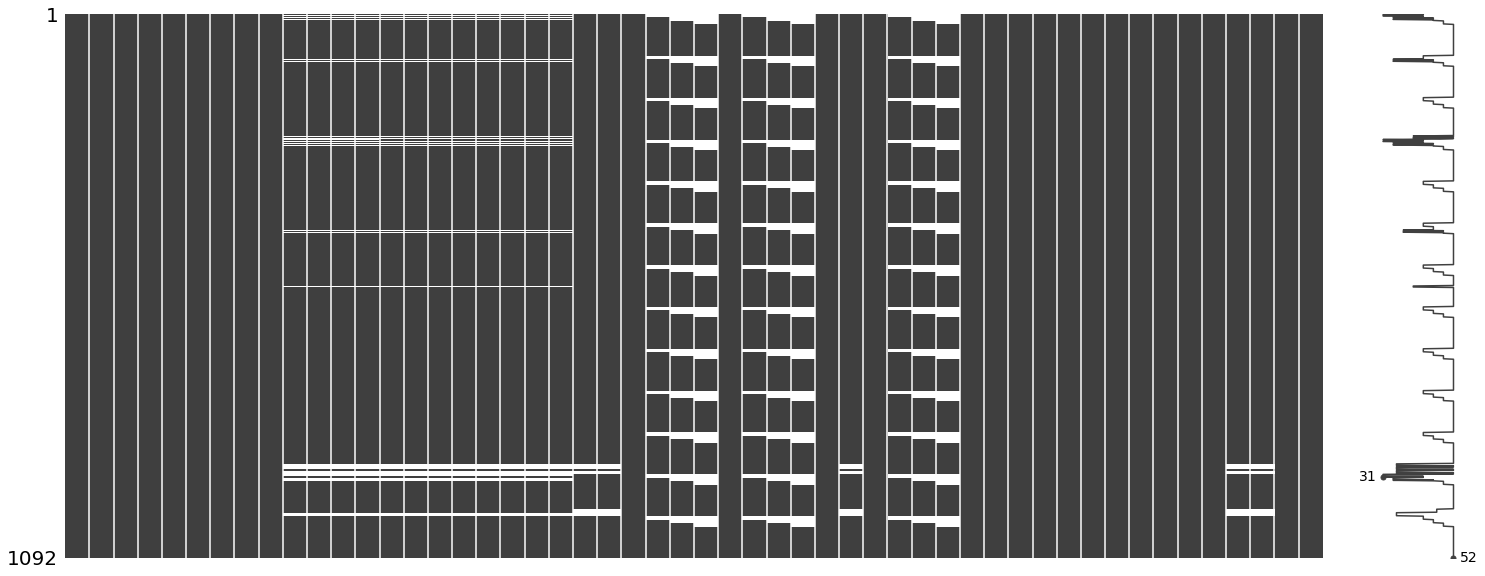

In [78]:
missingno.matrix(merged)

In [79]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,5.219800


In [80]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

In [81]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,5.219800


In [82]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022])

In [83]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['ημαθια', 'θεσσαλονικη', 'κιλκις', 'πελλα', 'πιερια', 'σερρες',
       'χαλκιδικη'], dtype=object)

In [84]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [85]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,ημαθια,2010,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
1,θεσσαλονικη,2010,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000
2,κιλκις,2010,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000
3,πελλα,2010,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000
4,πιερια,2010,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.000000,27.000000,70.741701,556.000000,174.000000,174.000000,437.000000
5,σερρες,2010,15.750000,19.833333,45.075758,882.274952,39.000000,-5.000000,44.000000,9.833333,25.666667,26.166667,4.500000,1423.000000,319.000000,11.000000,73.019474,505.000000,173.000000,270.000000,446.000000
6,χαλκιδικη,2010,16.083333,17.833333,45.726496,746.151743,37.000000,-2.000000,39.000000,11.333333,25.166667,25.333333,7.166667,1379.000000,385.000000,5.000000,93.001363,529.000000,168.000000,214.000000,430.000000
7,ημαθια,2011,13.916667,19.500000,48.750000,802.222292,35.000000,-5.000000,40.000000,13.666667,23.666667,23.666667,4.500000,874.000000,148.000000,14.000000,49.642554,296.000000,108.000000,108.000000,257.000000
8,θεσσαλονικη,2011,15.166667,20.833333,49.603175,884.033456,38.000000,-4.000000,42.000000,13.500000,26.000000,26.333333,5.166667,876.000000,143.000000,19.000000,56.510522,283.000000,113.000000,205.000000,234.000000
9,κιλκις,2011,15.208333,23.416667,45.915033,943.267612,40.000000,-11.000000,51.000000,12.833333,26.666667,27.166667,4.833333,798.000000,151.000000,5.000000,65.470755,265.000000,128.000000,195.000000,193.000000


In [86]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [87]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'ημαθια')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.435606,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,1043.454545,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
7,2010-02,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.736428,1.371205,6.168909,4.651637,NaN,NaN,2.664997,-0.644107,NaN,NaN,10.208667,4.053816,4.416953,2.318399,NaN,NaN,71.780864,142.317966,247.123971,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,566.545455,-4.002083,11.714000,285.842680,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
14,2010-03,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3,2010,0.306789,0.153101,-0.138970,-0.153101,0.299181,0.139387,-0.144685,-0.139387,0.042870,0.046756,0.048620,0.046756,15.908721,3.687326,6.168909,6.736824,15.059269,NaN,2.664997,1.525188,3.558160,NaN,3.788843,9.798023,4.416953,4.131006,9.308714,NaN,28.648361,56.408068,437.915193,10.741935,-0.000000,-0.000000,1.000000,0.000000,0.944883,0.289609,1417.109091,0.445636,21.507455,117.454131,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
21,2010-04,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,4,2010,0.406513,0.144527,-0.232916,-0.144527,0.417933,0.143252,-0.242450,-0.143252,0.042646,0.045180,0.040471,0.045180,22.364242,7.348303,6.168909,6.736824,15.908721,22.573057,2.664997,1.525188,3.687326,6.590470,2.476825,14.856273,4.416953,4.131006,9.798023,14.581764,17.905755,37.747035,517.210047,15.066667,-0.000000,-0.033333,0.866025,-0.500000,0.965525,-0.211237,2164.836364,4.902364,27.275455,74.304749,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
28,2010-05,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,5,2010,0.553118,0.207209,-0.325464,-0.207209,0.534235,0.195843,-0.319145,-0.195843,0.055996,0.051456,0.034650,0.051456,27.508698,13.070774,6.168909,6.736824,15.908721,15.908721,2.664997,1.525188,3.687326,3.687326,3.953829,20.289736,4.416953,4.131006,9.798023,9.798023,25.573667,49.924291,613.462381,19.419355,-0.000000,-0.000000,0.500000,-0.866025,0.735239,-0.659841,2626.109091,9.828182,31.784182,122.568711,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
35,2010-06,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,6,2010,0.602921,0.230007,-0.360372,-0.230007,0.597983,0.228508,-0.355233,-0.228508,0.058274,0.048741,0.026554,0.048741,29.

In [88]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [89]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [90]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [92]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

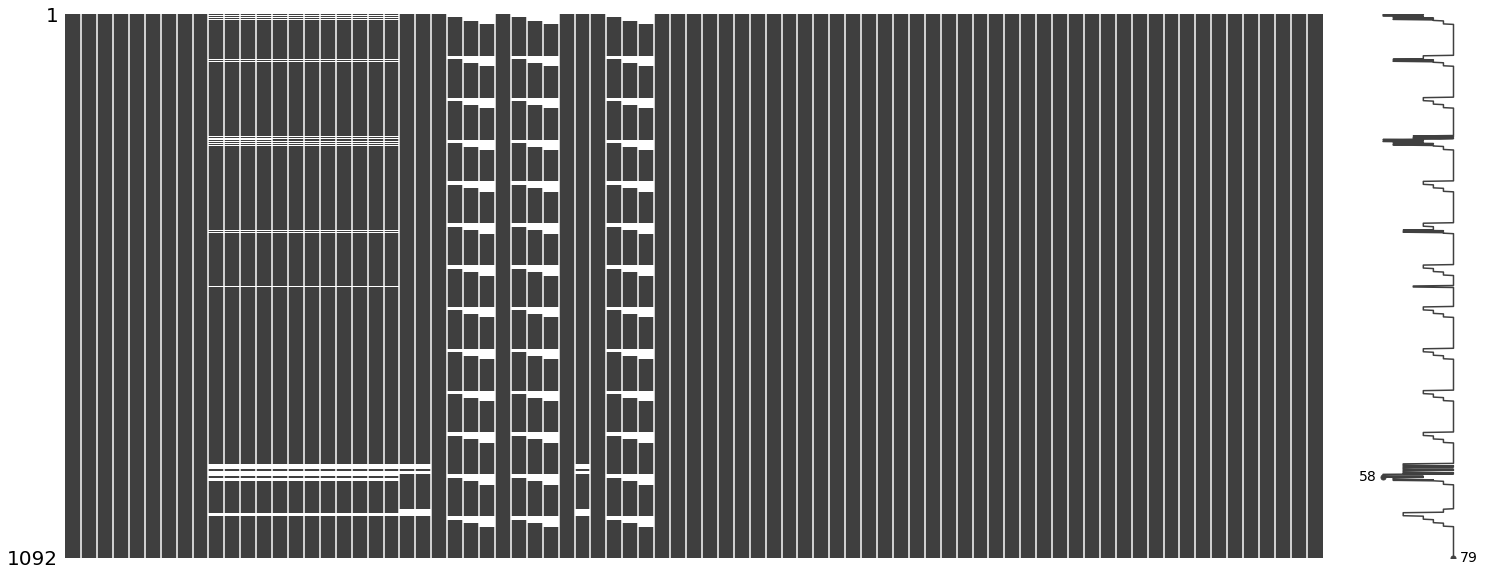

In [93]:
missingno.matrix(dataset)

In [94]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [95]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [96]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [97]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [98]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

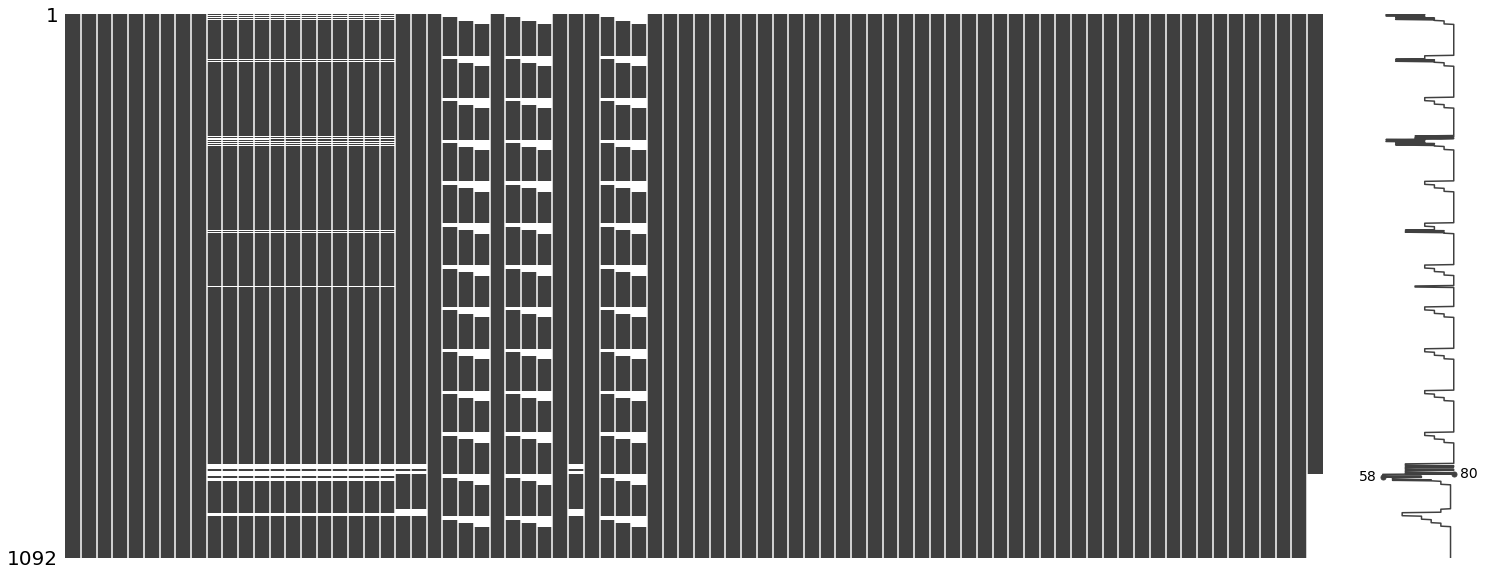

In [99]:
missingno.matrix(dataset)

In [100]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [101]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [102]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [104]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [105]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

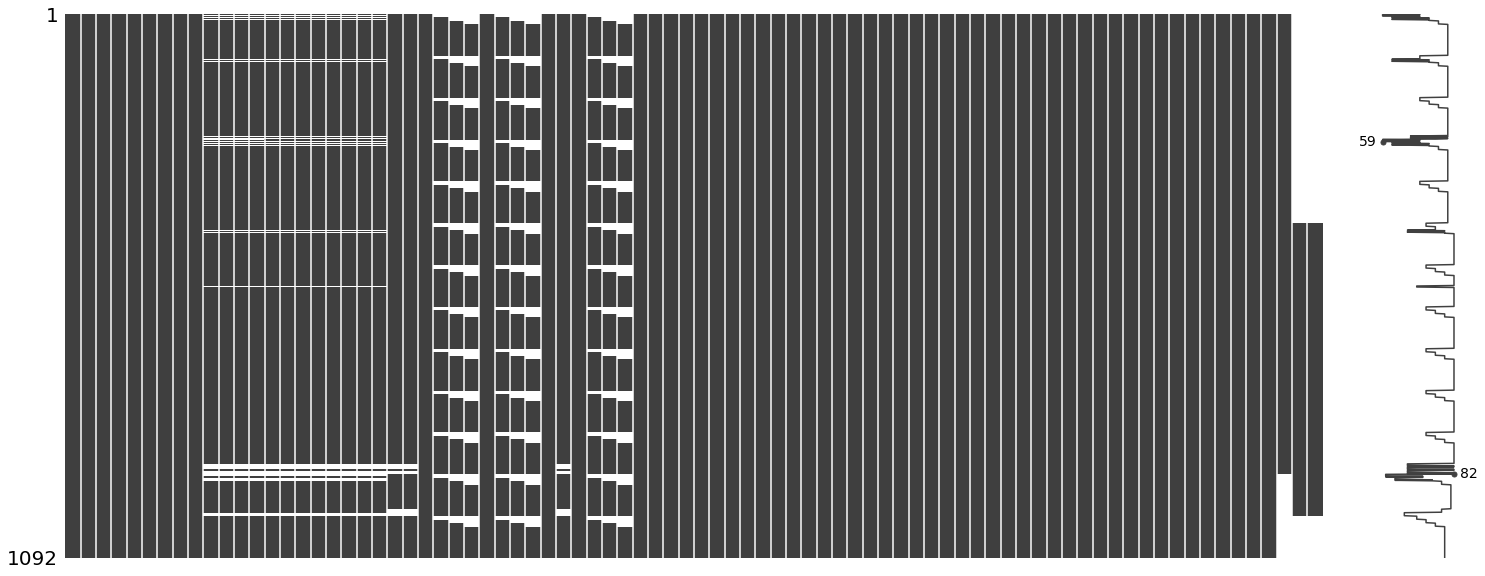

In [106]:
missingno.matrix(dataset)

In [107]:
missing = describe_dataframe(dataset)

In [108]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,5.219800


In [109]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.435606,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,1043.454545,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,740.125984,-2.877717,13.860079,42.311748,0,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,631.285714,-4.895934,12.183407,53.173589,0,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,7.387097,0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,869.318182,-3.823409,11.261136,81.491186,0,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN
4,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,1130.755556,1.550444,15.961111,81.927242,0,15.916667,18.33333

In [110]:
dataset.reset_index(inplace=True, drop=True)

In [111]:
dataset['cases'].value_counts()

0     954
1      39
2      22
3      17
4      10
5       8
10      5
11      5
7       5
6       5
12      4
13      3
17      2
8       2
20      2
50      1
9       1
16      1
41      1
34      1
27      1
40      1
49      1
36      1
Name: cases, dtype: int64

In [112]:
dataset['cases'].sum()

863

In [113]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.435606,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,1043.454545,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,740.125984,-2.877717,13.860079,42.311748,0,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,631.285714,-4.895934,12.183407,53.173589,0,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,7.387097,0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,869.318182,-3.823409,11.261136,81.491186,0,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN
4,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,1130.755556,1.550444,15.961111,81.927242,0,15.916667,18.33333

In [117]:
dataset.drop(columns = ['week','day_sin','day_cos','month_sin','month_cos','week_sin','week_cos'], inplace = True)

In [118]:
cols = dataset.columns

In [119]:
cols

Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'lst', 'lst_jan_mean', 'lst_feb_mean',
       'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'mosq_pred',
       'monthly_lst_min', 'monthly_lst_max', 'monthly_acc_prec', 'cases',
       'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9',
       'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17',
       'bio18', 'bio19', 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
       'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 

In [120]:
len(cols)

75

In [121]:
# check columns

In [125]:
final_columns = ['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME',
                 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
                 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std',
                 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
                 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
                 'bio17', 'bio18', 'bio19', 
                 'lst', 'lst_day', 'lst_night', 'monthly_lst_min', 'monthly_lst_max',
                 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
                 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 
                 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 
                 'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
                 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 
                 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL','mosq_pred', 'cases']

In [126]:
len(final_columns)

75

In [127]:
dataset_final = dataset[final_columns].copy()

In [128]:
dataset_final

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,22.215876,40.552658,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,4.435606,6.168909,2.702302,-0.015091,12.092545,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,81.134845,15.306163,25.795942,35.973005,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN,1043.454545,0
1,23.139532,40.695359,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,4.816764,7.923406,1.710122,-2.877717,13.860079,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,42.311748,7.807795,13.338001,19.783772,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN,740.125984,0
2,22.758634,41.016242,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,3.765541,7.190461,0.340620,-4.895934,12.183407,5.888491,NaN,NaN,NaN,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,53.173589,9.279576,14.213017,18.993597,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN,631.285714,0
3,22.109199,40.888821,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000,3.694941,6.414831,0.975051,-3.823409,11.261136,6.293877,NaN,NaN,NaN,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,81.491186,14.713423,22.905129,32.657020,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN,869.318182,0
4,22.441443,40.269748,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.000000,27.000000,70.741701,556.000000,174.000000,174.000000,437.000000,6.091283,8.354315,3.828251,1.550444,15.961111,8.601499,NaN,NaN,NaN,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,81.927242,15.859868,27.160592,39.731443,10433.000000,40170.000000,12062.000000,62665.000000,10152.000000,40273.000000,14620.000000,65045.000000,1725.030000,NaN,NaN,1130.755556,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

<AxesSubplot:>

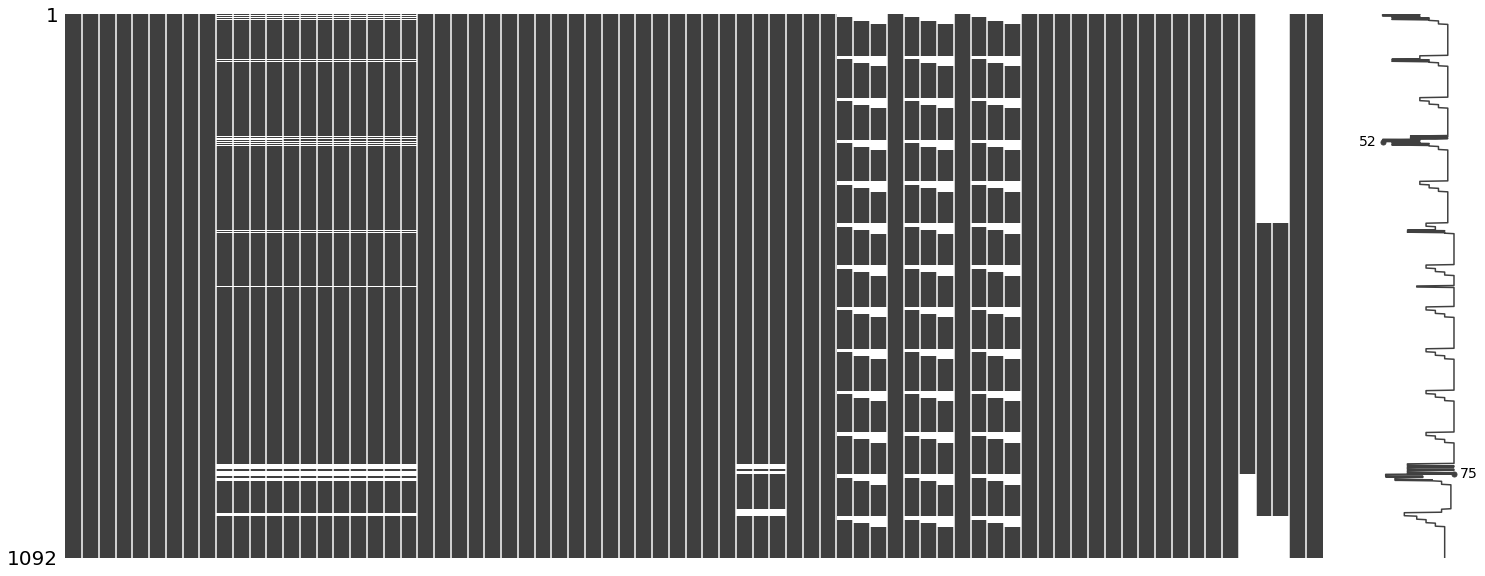

In [129]:
missingno.matrix(dataset_final)

In [130]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)